# Ray casting through the hierarchical grid

`RayTracer.cast_ray(x, y, dx, dy)` (`rust/src/ray_tracing.rs`) returns every 0.5 m point whose cell a horizontal ray crosses, ignoring altitude, nearest first. It walks the 3×3 tree from the root, descending only into the children the ray actually enters (an exact ray–square test), nearest child first, and skips empty subtrees altogether.

Example: a ray from downtown Vancouver (Robson & Granville area) heading WNW through the West End and out over English Bay, until it leaves the dataset.

Run with the **viewfinder-backend** kernel.

In [1]:
import math
import pathlib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from viewfinder_core import RayTracer

u16_path = pathlib.Path("~/data/lidar-vancouver-u16").expanduser()
rt = RayTracer(u16_path)
index = pd.read_csv(u16_path / "index.csv")


def latlon_to_utm(lat, lon):
    """UTM (EPSG:26910) from lat/lon using the corner coordinates in index.csv (no pyproj needed).
    Inverts the bilinear lat/lon interpolation of the containing parcel; accurate to a few cm."""
    t = index[(index.lat_sw <= lat) & (index.lat_nw >= lat) & (index.lon_nw <= lon) & (index.lon_ne >= lon)].iloc[0]
    u = (lon - t.lon_nw) / (t.lon_ne - t.lon_nw)
    v = (t.lat_nw - lat) / (t.lat_nw - t.lat_sw)
    return t.x_start + u * (t.x_end - t.x_start), t.y_start + v * (t.y_end - t.y_start)

In [2]:
observer = latlon_to_utm(49.2827, -123.1207)  # downtown, near Granville & Georgia
bearing = 275  # degrees clockwise from north: WNW over the West End towards English Bay
direction = (math.sin(math.radians(bearing)), math.cos(math.radians(bearing)))

start = time.perf_counter()
hits = rt.cast_ray(*observer, *direction)
elapsed = time.perf_counter() - start

ray = pd.DataFrame(hits, columns=["x", "y", "altitude"])
ray["altitude"] = ray["altitude"].astype(float)  # None -> NaN
ray["distance"] = np.hypot(ray.x - observer[0], ray.y - observer[1])
print(f"observer UTM {observer[0]:.2f}, {observer[1]:.2f}; ground altitude {rt.altitude_at(*observer):.1f} m")
print(f"{len(ray):,} points crossed in {elapsed * 1000:.1f} ms; ray leaves the dataset after {ray.distance.max():,.0f} m")
print(f"points without data: {ray.altitude.isna().sum():,} ({ray.altitude.isna().mean():.0%})")
ray.head()

observer UTM 491221.95, 5458890.34; ground altitude 30.8 m
6,948 points crossed in 0.9 ms; ray leaves the dataset after 3,235 m
points without data: 1,626 (23%)


,x,y,altitude,distance
0,491221.75,5458890.25,30.820432,0.214810
1,491221.25,5458890.25,30.820432,0.701429
2,491220.75,5458890.25,30.820432,1.199109
3,491220.25,5458890.25,30.802147,1.698153
4,491220.25,5458890.75,30.811290,1.745137


In [3]:
# Sanity checks against the grid itself
assert ray.distance.is_monotonic_increasing or (ray.distance.diff().dropna() > -rt.cell_size * math.sqrt(2)).all()
# Every reported point is within half a cell diagonal of the ray line
perpendicular = (ray.x - observer[0]) * direction[1] - (ray.y - observer[1]) * direction[0]
print(f"max distance from ray line: {perpendicular.abs().max():.3f} m (limit {rt.cell_size * math.sqrt(2) / 2:.3f} m)")
# Altitudes agree with direct lookups
sample = ray.sample(2000, random_state=0)
direct = np.array([np.nan if (a := rt.altitude_at(x, y)) is None else a for x, y in zip(sample.x, sample.y)])
print("altitudes match direct lookups:", np.allclose(direct, sample.altitude, equal_nan=True))

max distance from ray line: 0.271 m (limit 0.354 m)
altitudes match direct lookups: True


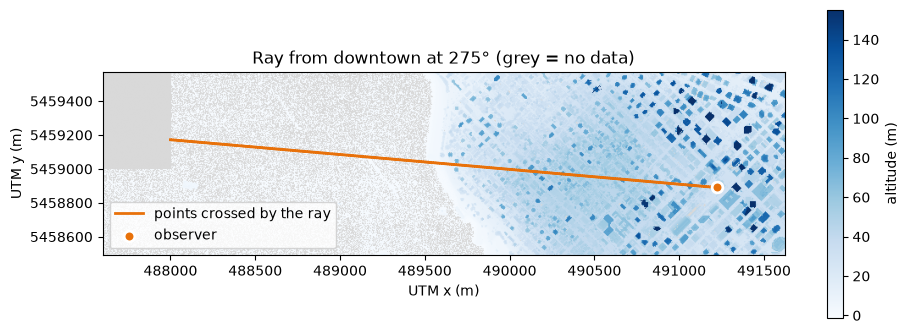

In [4]:
# Overview: the area around the ray at 5 m sampling, with the ray drawn on top
margin = 400
x0, x1 = ray.x.min() - margin, ray.x.max() + margin
y0, y1 = ray.y.min() - margin, ray.y.max() + margin
step = 5.0
xs, ys = np.arange(x0, x1, step), np.arange(y1, y0, -step)
area = np.array([[np.nan if (a := rt.altitude_at(x, y)) is None else a for x in xs] for y in ys])

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.get_cmap("Blues").with_extremes(bad="#d9d9d9")
image = ax.imshow(area, cmap=cmap, extent=[x0, x1, y0, y1], vmax=np.nanpercentile(area, 99.5))
ax.plot(ray.x, ray.y, color="#e8710a", lw=2, label="points crossed by the ray")
ax.scatter(*observer, s=60, color="#e8710a", edgecolor="white", linewidth=2, zorder=3, label="observer")
ax.set_title(f"Ray from downtown at {bearing}° (grey = no data)")
ax.set_xlabel("UTM x (m)")
ax.set_ylabel("UTM y (m)")
ax.ticklabel_format(useOffset=False, style="plain")
ax.legend(loc="lower left")
fig.colorbar(image, ax=ax, label="altitude (m)", shrink=0.8)
plt.show()

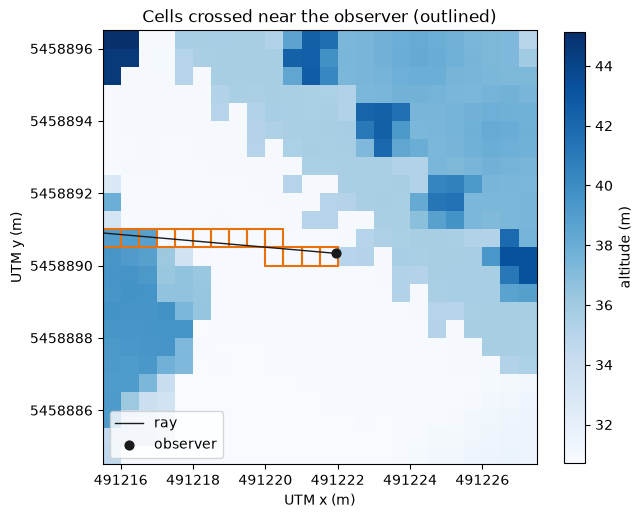

In [5]:
# Zoom on the first 12 m: every 0.5 m cell around the observer, with the ones the ray crosses outlined
half_window = 6.0
cell = rt.cell_size
column0 = round((observer[0] - half_window - rt.x_start) / cell)
row0 = round((rt.y_start - (observer[1] + half_window)) / cell)
size = round(2 * half_window / cell)
patch = np.array([[np.nan if (a := rt.altitude(row0 + r, column0 + c)) is None else a for c in range(size)] for r in range(size)])
left, top = rt.x_start + (column0 - 0.5) * cell, rt.y_start - (row0 - 0.5) * cell

near = ray[(ray.x.between(left, left + size * cell)) & (ray.y.between(top - size * cell, top))]
fig, ax = plt.subplots(figsize=(7, 7))
image = ax.imshow(patch, cmap=cmap, extent=[left, left + size * cell, top - size * cell, top])
for x, y in zip(near.x, near.y):
    ax.add_patch(Rectangle((x - cell / 2, y - cell / 2), cell, cell, fill=False, edgecolor="#e8710a", lw=1.5))
end = (observer[0] + direction[0] * 3 * half_window, observer[1] + direction[1] * 3 * half_window)
ax.plot([observer[0], end[0]], [observer[1], end[1]], color="#1a1a1a", lw=1, label="ray")
ax.scatter(*observer, s=40, color="#1a1a1a", zorder=3, label="observer")
ax.set_xlim(left, left + size * cell)
ax.set_ylim(top - size * cell, top)
ax.set_title("Cells crossed near the observer (outlined)")
ax.set_xlabel("UTM x (m)")
ax.set_ylabel("UTM y (m)")
ax.ticklabel_format(useOffset=False, style="plain")
ax.legend(loc="lower left")
fig.colorbar(image, ax=ax, label="altitude (m)", shrink=0.8)
plt.show()

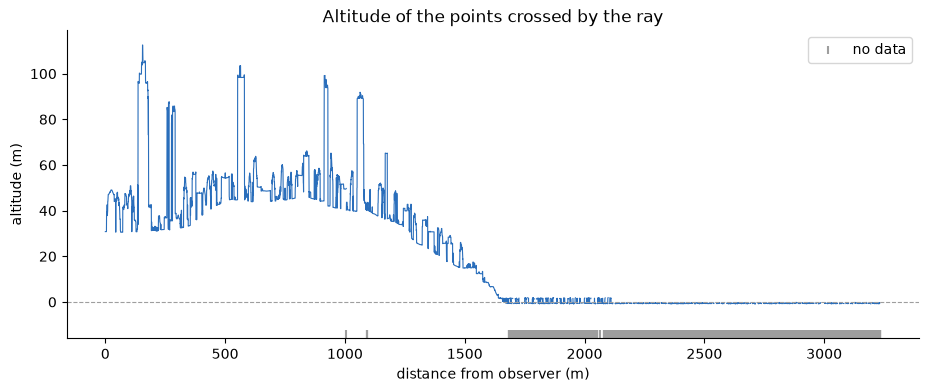

In [6]:
# Altitude of every crossed point along the ray: the West End towers, then the drop to English Bay
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ray.distance, ray.altitude, color="#2a6ebb", lw=0.8)
missing = ray[ray.altitude.isna()]
ax.scatter(missing.distance, np.full(len(missing), -14), marker="|", s=40, color="#9e9e9e", label="no data")
ax.axhline(0, color="#9e9e9e", lw=0.8, ls="--")
ax.set_title("Altitude of the points crossed by the ray")
ax.set_xlabel("distance from observer (m)")
ax.set_ylabel("altitude (m)")
ax.set_ylim(-16, None)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right")
plt.show()

In [7]:
# Cost: rays in every direction from the same observer
timings = []
for bearing_deg in range(0, 360, 5):
    d = (math.sin(math.radians(bearing_deg)), math.cos(math.radians(bearing_deg)))
    start = time.perf_counter()
    n = len(rt.cast_ray(*observer, *d))
    timings.append({"bearing": bearing_deg, "points": n, "ms": (time.perf_counter() - start) * 1000})
timings = pd.DataFrame(timings)
print(f"{len(timings)} rays: {timings.points.sum():,} points in {timings.ms.sum():.0f} ms "
      f"({timings.ms.sum() * 1e6 / timings.points.sum():.0f} ns per point, including building the Python list)")
timings.describe().round(1)

72 rays: 1,191,380 points in 144 ms (121 ns per point, including building the Python list)


,bearing,points,ms
count,72.0,72.0,72.0
mean,177.5,16546.9,2.0
std,104.6,9105.5,2.4
min,0.0,3120.0,0.3
25%,88.8,7883.2,0.9
50%,177.5,16771.5,1.6
75%,266.2,24168.2,2.7
max,355.0,33585.0,20.1
